# Analisis Pembersihan: Data Test Drive Asli (`train.csv`)

Audit atribut-per-atribut atas apa yang dilakukan `clean_telemetry.py --trim-idle`
terhadap log test drive asli (2026-07-04, 8.236 baris, ~10 Hz dengan jam 1 Hz).
Untuk setiap atribut: sinyal mentah, vonis **NOISE / NATURAL**, dan apa yang
diubah oleh script — mengikuti protokol yang sama dengan notebook manual
TestDrive.

Masalah yang benar-benar ada di dataset ini:

| Masalah | Lokasi | Penanganan yang benar |
|---|---|---|
| ~400 sampel hilang (NaN) per kolom | dropout logger, tersebar | interpolasi run pendek |
| Logging idle sebelum race | ~800 baris pertama, mobil diam | trim (`--trim-idle`) |
| Timestamp resolusi 1 detik pada data 10 Hz | `recorded_at` | pertahankan baris, lewati dedupe timestamp |
| Kolom teks (`mode`, `recorded_at`) | harus selamat dari pembersihan numerik | pertahankan sebagai meta |
| Segelintir spike sensor | vinFC (7), mslAltitude (5), velocity (2) | deteksi MAD + interpolasi |

Selain itu semuanya adalah **fisika natural dan wajib lolos tanpa tersentuh**.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv('data/train.csv').set_index('id')
cl  = pd.read_csv('data/train_cleaned.csv').set_index('id')
with open('reports/train_cleaned_report.json') as f:
    report = json.load(f)

# Sumbu-x = waktu tempuh (kolom timeS, resolusi 0.1 s).
# Pada data mentah timeS punya lubang NaN — diinterpolasi KHUSUS untuk sumbu,
# nilai datanya sendiri tidak diubah.
t_raw = raw['timeS'].interpolate(limit_direction='both')
t_cl  = cl['timeS']

RAW_C, CLEAN_C = '#eb6834', '#2a78d6'      # oranye = mentah, biru = cleaned
INK, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#e1e0d9', '#c3c2b7'
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'font.size': 10, 'axes.titlelocation': 'left',
                     'axes.titleweight': 'bold', 'axes.titlecolor': INK})

def style_ax(ax):
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(AXIS)
    ax.grid(axis='y', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9)

def compare(col, ylabel, title):
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
    a1.plot(t_raw, raw[col], color=RAW_C, lw=1.0)
    a1.set_title(f'{title} — mentah (uncleaned)')
    a2.plot(t_cl, cl[col], color=CLEAN_C, lw=1.0)
    a2.set_title(f'{title} — hasil script (cleaned)')
    a2.set_xlabel('waktu tempuh (s)', color=MUTED)
    for a in (a1, a2):
        a.set_ylabel(ylabel, color=MUTED)
        style_ax(a)
    plt.tight_layout()
    plt.show()

print(f"baris mentah: {len(raw)}   baris cleaned: {len(cl)}")
print(f"kolom timestamp yang dipakai: {report.get('ts_column_used')}")
print(f"baris idle yang dipangkas: {report.get('idle_rows_trimmed')}")
for w in report['warnings']:
    print('PERINGATAN:', w)

baris mentah: 8236   baris cleaned: 7432
kolom timestamp yang dipakai: recorded_at
baris idle yang dipangkas: {'leading': 804, 'trailing': 0}
PERINGATAN: 'recorded_at' is low-resolution (90% repeated values): timestamp dedupe skipped (rows kept)


---
## 1. Cakupan baris: pemangkasan idle

`--trim-idle` membuang baris di awal/akhir saat mobil tidak bergerak. Ia hanya
bisa melihat *gerakan* — baris warm-up setelah mobil pertama kali menggelinding
tetap dipertahankan, karena tanpa informasi lap, "bergerak sebelum race" dan
"sedang race" terlihat identik. (`assign_laps.py` yang menuntaskannya dengan
menandai baris tersebut `lap_number = NaN`.)

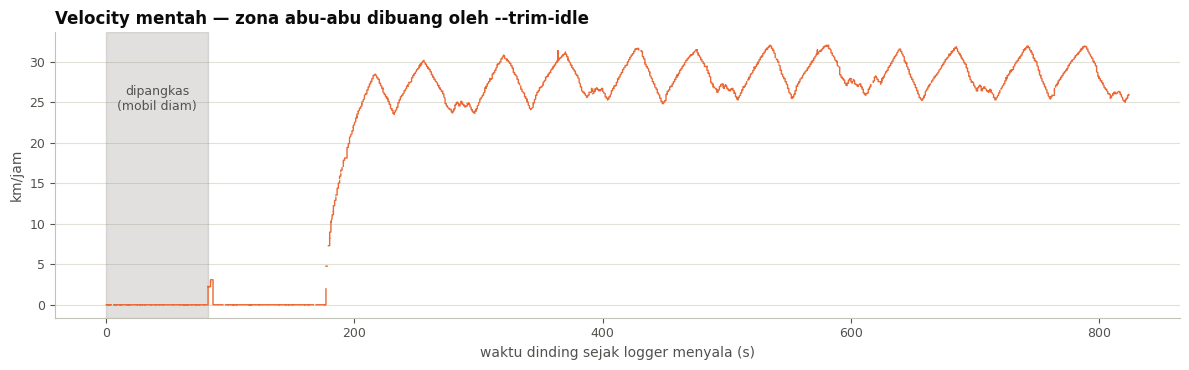

dipertahankan mulai detik ke-82 dari logger menyala (804 baris idle dibuang)


In [2]:
# Untuk grafik cakupan ini dipakai waktu dinding (recorded_at), bukan timeS:
# saat mobil diam, counter timeS nyaris tidak berjalan sehingga zona idle akan
# menyusut jadi tak terlihat. Waktu dinding menunjukkan lebar sebenarnya.
wall = (pd.to_datetime(raw['recorded_at'], format='mixed')
        - pd.to_datetime(raw['recorded_at'], format='mixed').min()).dt.total_seconds()

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(wall, raw['velocity'], color=RAW_C, lw=1.0)
first_w = float(wall.loc[cl.index.min()])
ax.axvspan(0, first_w, color='#898781', alpha=0.25)
ax.text(first_w / 2, 24, 'dipangkas\n(mobil diam)', ha='center', fontsize=9, color=MUTED)
ax.set_title('Velocity mentah — zona abu-abu dibuang oleh --trim-idle')
ax.set_xlabel('waktu dinding sejak logger menyala (s)', color=MUTED)
ax.set_ylabel('km/jam', color=MUTED)
style_ax(ax)
plt.tight_layout(); plt.show()
print(f"dipertahankan mulai detik ke-{first_w:.0f} dari logger menyala "
      f"({len(raw) - len(cl)} baris idle dibuang)")

---
## 2. Velocity — NATURAL, dengan sampel hilang

Grafik mentahnya adalah pola pulse-and-glide yang sehat (tidak ada spike gaya
999 di log ini — sensornya berperilaku baik). Cacatnya adalah ~430 dropout NaN
tersebar, terlihat sebagai lubang pada garis mentah. Vonis: **sinyal NATURAL +
data hilang**; tugas script hanyalah menjembatani lubangnya.

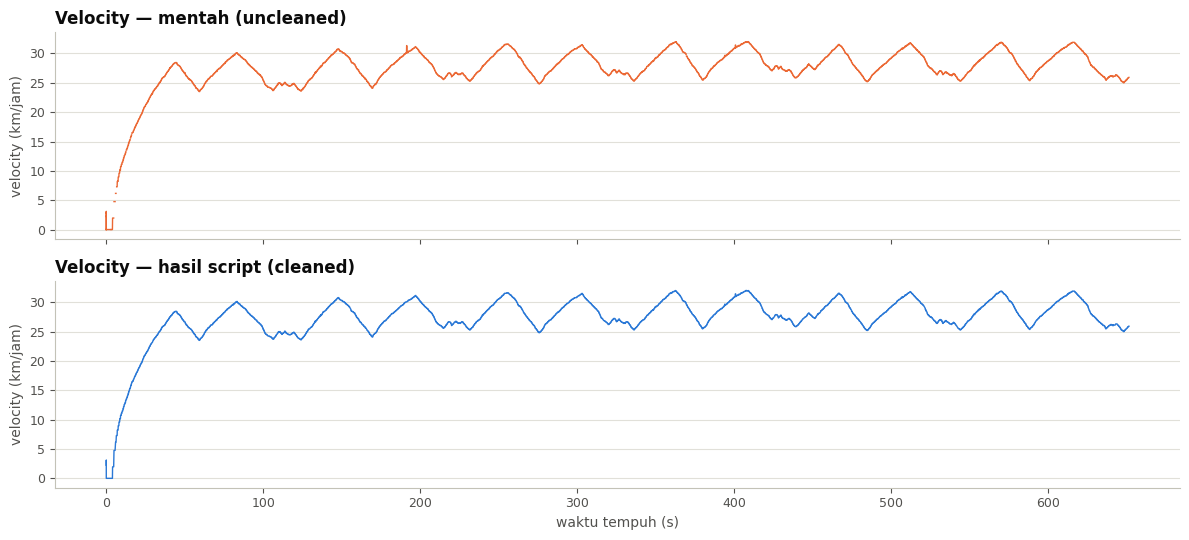

outlier MAD: 2   zero-glitch: 0   diinterpolasi: 390


In [3]:
compare('velocity', 'velocity (km/jam)', 'Velocity')
v = report['columns']['velocity']
print(f"outlier MAD: {v.get('mad_outliers', 0)}   zero-glitch: {v.get('zero_glitches', 0)}   diinterpolasi: {v.get('interpolated', 0)}")

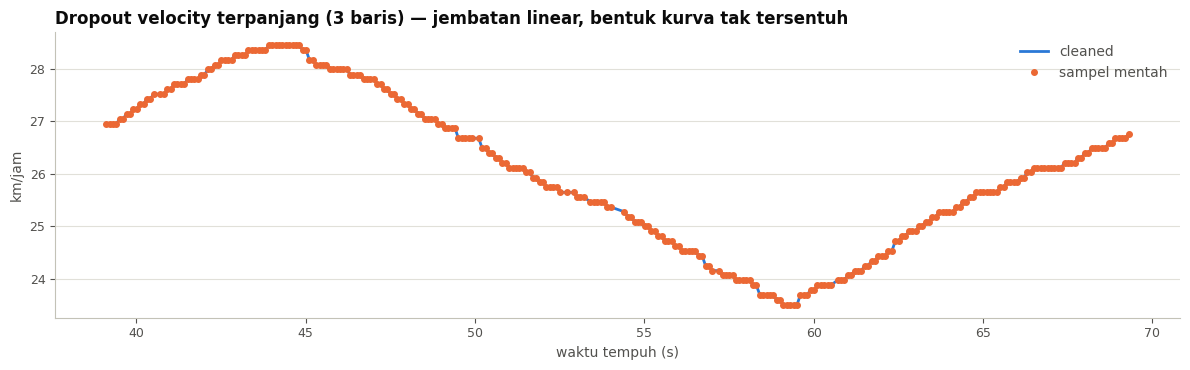

In [4]:
# zoom pada run NaN terpanjang: titik mentah, jembatan hasil cleaning
sub = raw.loc[cl.index]
na = sub['velocity'].isna()
grp = (na != na.shift()).cumsum()
runs = na.groupby(grp).agg(['sum'])
top = runs[runs['sum'] > 0]['sum'].idxmax()
ids = na[grp == top].index
lo_t = float(t_cl.loc[ids.min()]) - 15
hi_t = float(t_cl.loc[ids.max()]) + 15

m_cl = (t_cl >= lo_t) & (t_cl <= hi_t)
m_raw = (t_raw >= lo_t) & (t_raw <= hi_t)
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(t_cl[m_cl], cl.loc[m_cl, 'velocity'], color=CLEAN_C, lw=2.0, label='cleaned')
ax.plot(t_raw[m_raw], raw.loc[m_raw, 'velocity'], 'o', ms=4, color=RAW_C, label='sampel mentah')
ax.set_title(f'Dropout velocity terpanjang ({int(runs.loc[top, "sum"])} baris) — jembatan linear, bentuk kurva tak tersentuh')
ax.set_xlabel('waktu tempuh (s)', color=MUTED); ax.set_ylabel('km/jam', color=MUTED)
ax.legend(frameon=False, labelcolor=MUTED)
style_ax(ax)
plt.tight_layout(); plt.show()

---
## 3. vinFC — voltage sag NATURAL, dibuktikan dengan kolom `mode`

Dataset ini punya sesuatu yang di notebook manual TestDrive harus disimpulkan
secara tidak langsung: kolom **`mode`** eksplisit (`gas` = motor menyala,
`glide` = meluncur). Dengan mengarsir fase gas, fisikanya tak terbantahkan —
tegangan turun *tepat* saat gas dan pulih saat glide. Itu adalah *voltage sag*
akibat hambatan dalam, bukan noise, dan script tidak boleh menghaluskannya.
Script hanya menandai 7 spike tunggal terisolasi dari 7.432 baris.

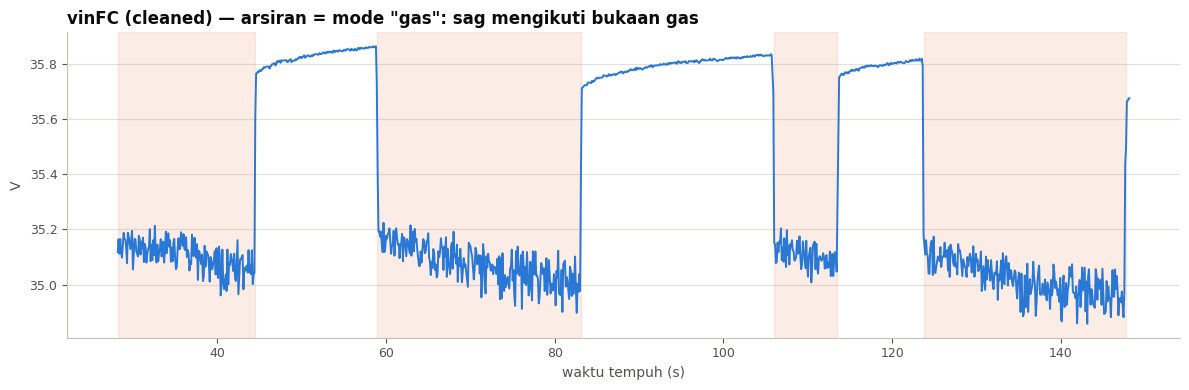

vinFC: outlier MAD yang diinterpolasi: 7 dari 7432 baris (0.09% tersentuh) — sag-nya sendiri tidak diubah


In [5]:
seg = cl.iloc[1200:2400]
x = seg['timeS'].to_numpy()
fig, ax = plt.subplots(figsize=(12, 4))
gas = (seg['mode'] == 'gas').to_numpy()
edges = np.flatnonzero(np.diff(gas.astype(int)))
bounds = np.r_[0, edges + 1, len(gas)]
for i in range(len(bounds) - 1):
    if gas[bounds[i]]:
        ax.axvspan(x[bounds[i]], x[bounds[i + 1] - 1], color=RAW_C, alpha=0.12)
ax.plot(x, seg['vinFC'], color=CLEAN_C, lw=1.4)
ax.set_title('vinFC (cleaned) — arsiran = mode "gas": sag mengikuti bukaan gas')
ax.set_xlabel('waktu tempuh (s)', color=MUTED); ax.set_ylabel('V', color=MUTED)
style_ax(ax)
plt.tight_layout(); plt.show()

st = report['columns']['vinFC']
print(f"vinFC: outlier MAD yang diinterpolasi: {st.get('mad_outliers', 0)} dari {len(cl)} baris "
      f"({st['fraction_touched']:.2%} tersentuh) — sag-nya sendiri tidak diubah")

---
## 4. kmPerkWh — NATURAL, tak tersentuh · mslAltitude — 5 spike

Efisiensi punya struktur nyata (turun saat gas, naik saat glide) dan tidak ada
error code di log ini — script membiarkannya 100% identik. Altitude bergeser
di kisaran ~14–19 m dengan lima spike terisolasi yang tertangkap detektor MAD;
sisanya adalah goyangan altitude GPS yang normal (medan Surabaya memang datar,
jadi rentang sekecil itu masuk akal).

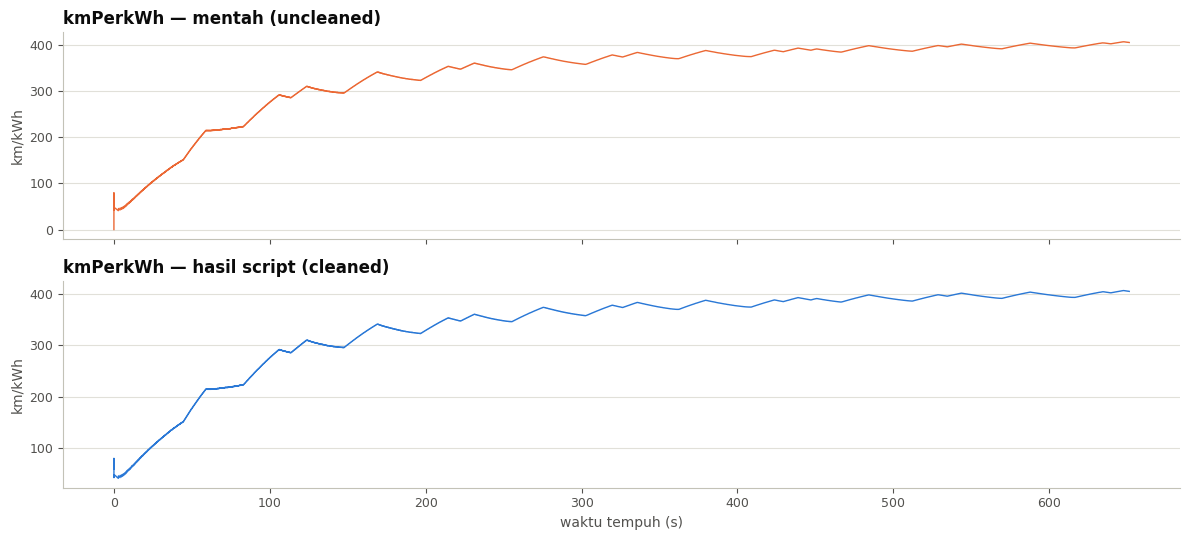

kmPerkWh identik dengan data mentah (pada baris non-NaN): 100.0%


In [6]:
compare('kmPerkWh', 'km/kWh', 'kmPerkWh')
print('kmPerkWh identik dengan data mentah (pada baris non-NaN):',
      f"{(cl['kmPerkWh'] == raw.loc[cl.index, 'kmPerkWh'])[raw.loc[cl.index, 'kmPerkWh'].notna()].mean():.1%}")

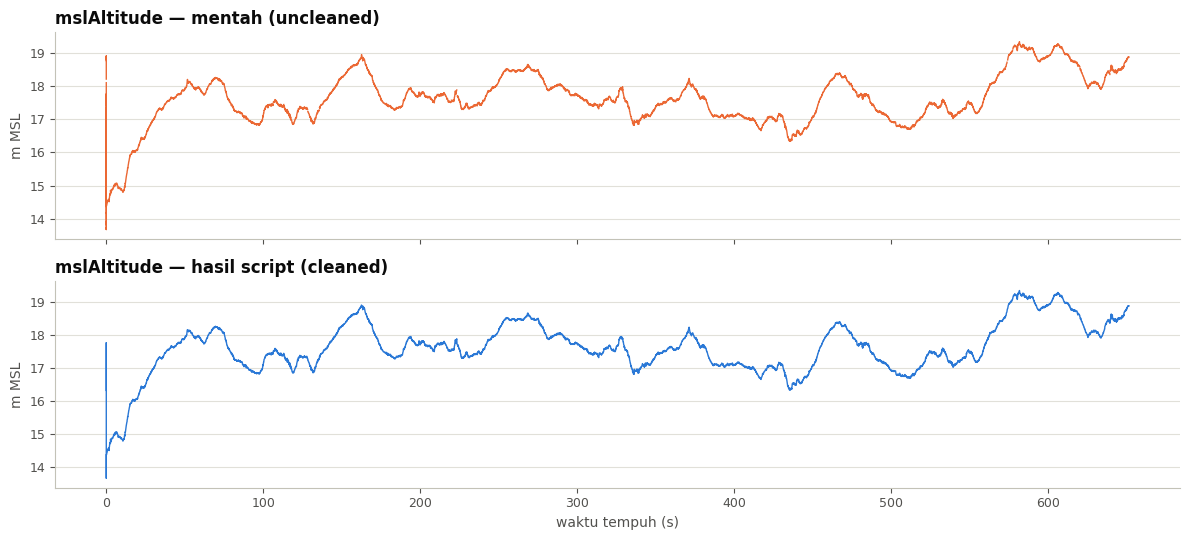

mslAltitude: outlier MAD: 5   diinterpolasi: 339


In [7]:
compare('mslAltitude', 'm MSL', 'mslAltitude')
st = report['columns']['mslAltitude']
print(f"mslAltitude: outlier MAD: {st.get('mad_outliers', 0)}   diinterpolasi: {st.get('interpolated', 0)}")

---
## 5. Rute GPS — NATURAL · kolom teks — terjaga

Rutenya menggambar lap sirkuit dengan bersih; script hanya mengisi dropout NaN.
Dan dua kolom teks yang akan hancur di tangan pembersih numerik naif (`mode`,
`recorded_at`) lolos bit-identik, dengan `lap_number` dilindungi sebagai kolom
pembukuan (tidak pernah diinterpolasi — mengarang nomor lap adalah omong
kosong).

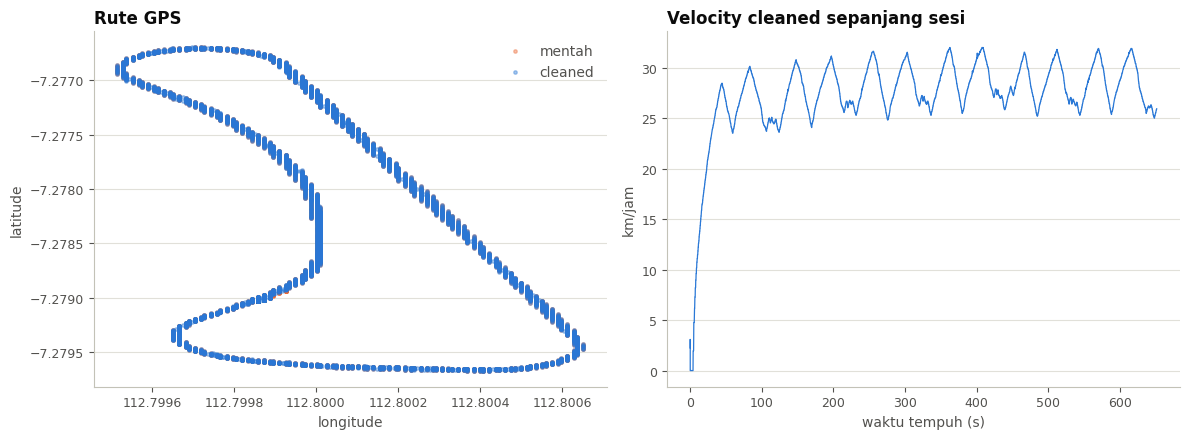

nilai mode terjaga: {'gas': 3792, 'glide': 3640}
recorded_at terjaga: 2026-07-04 08:03:26.000 -> 2026-07-04 08:15:48.000
timeS monotonik (kumulatif): True


In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.scatter(raw['longitude'], raw['latitude'], s=6, color=RAW_C, alpha=0.4, label='mentah')
a1.scatter(cl['longitude'], cl['latitude'], s=6, color=CLEAN_C, alpha=0.4, label='cleaned')
a1.set_title('Rute GPS')
a1.set_xlabel('longitude', color=MUTED); a1.set_ylabel('latitude', color=MUTED)
a1.legend(frameon=False, labelcolor=MUTED)
a1.ticklabel_format(useOffset=False)
a2.plot(t_cl, cl['velocity'], color=CLEAN_C, lw=0.9)
a2.set_title('Velocity cleaned sepanjang sesi')
a2.set_xlabel('waktu tempuh (s)', color=MUTED); a2.set_ylabel('km/jam', color=MUTED)
for a in (a1, a2): style_ax(a)
plt.tight_layout(); plt.show()

print('nilai mode terjaga:', cl['mode'].value_counts().to_dict())
print('recorded_at terjaga:', cl['recorded_at'].iloc[0], '->', cl['recorded_at'].iloc[-1])
print('timeS monotonik (kumulatif):', cl['timeS'].is_monotonic_increasing)

---
## 6. Ringkasan QC — apa saja yang dilakukan script pada dataset ini

In [9]:
rows = []
for col, st in report['columns'].items():
    fixes = {k: v for k, v in st.items() if k not in ('verdict', 'fraction_touched', 'treated_as')}
    rows.append({'kolom': col, 'tersentuh': f"{st.get('fraction_touched', 0):.2%}",
                 'vonis': st.get('verdict', 'meta/terjaga').split(' (')[0],
                 'tindakan': str(fixes) if fixes else '—'})
pd.DataFrame(rows).set_index('kolom')

,tersentuh,vonis,tindakan
kolom,,,
id,0.00%,OK,—
lap_number,0.00%,OK,—
mode,0.00%,OK,—
recorded_at,0.00%,OK,—
vinFC,0.09%,OK,"{'mad_outliers': 7, 'mad_window': 7, 'interpol..."
velocity,0.03%,OK,"{'mad_outliers': 2, 'mad_window': 7, 'interpol..."
kmPerkWh,0.00%,OK,—
mslAltitude,0.07%,OK,"{'mad_outliers': 5, 'mad_window': 7, 'interpol..."
timeS,0.00%,OK,{'interpolated': 355}


### Kesimpulan

Data asli ternyata jauh lebih sehat daripada simulasi worst-case: tidak ada
badai spike, tidak ada banjir duplikat — cacatnya adalah **sampel hilang (~5%
per kolom), logging idle sebelum race, dan jam yang kasar (resolusi 1 detik)**.
Script menangani ketiganya dengan benar: menginterpolasi dropout pendek,
memangkas baris mobil diam, mempertahankan semua baris meski timestamp
berulang, menjaga kolom teks, dan tidak menyentuh apa pun yang berupa fisika
(voltage sag, pulse-and-glide, ayunan efisiensi — semuanya bit-identik dengan
data mentah).

Pembandingan silang dengan referensi hasil pembersihan manual ada di
`03_Script_vs_Real_Cleaning.ipynb`: 95–100% identik di semua atribut bersama.